In [23]:
import pandas as pd
import pandas_ta as ta

df = pd.read_csv("../../data/MSFT.USUSD_Candlestick_1_D_ASK_05.10.2022-05.10.2024.csv")
df=df[-300:]
df=df[df['Volume']!=0]
df["Gmt time"]=df["Gmt time"].str.replace(".000","")
df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')

## Take the rolling atr so the yaxis doesn't shake too much 
df["atr"] = ta.atr(high=df.High, low=df.Low, close=df.Close)
df["atr"] = df.atr.rolling(window=30).mean()

df.reset_index(drop=True, inplace=True)

df

,Gmt time,Open,High,Low,Close,Volume,atr
0,2023-12-11 22:00:00,370.984,374.444,370.484,374.353,54.8868,NaN
1,2023-12-12 22:00:00,376.624,377.704,370.813,374.363,76.9680,NaN
2,2023-12-13 22:00:00,373.403,373.893,364.203,366.134,73.1748,NaN
3,2023-12-14 22:00:00,366.823,372.393,366.823,369.103,67.7592,NaN
4,2023-12-17 22:00:00,369.693,373.004,368.784,372.603,53.2428,NaN
...,...,...,...,...,...,...,...
200,2024-09-29 21:00:00,428.064,430.354,425.404,429.844,27.2120,7.915056
201,2024-09-30 21:00:00,428.473,428.483,418.873,420.784,41.9950,7.884395
202,2024-10-01 21:00:00,422.623,422.623,416.774,417.413,24.3330,7.859636
203,2024-10-02 21:00:00,417.893,419.624,414.374,416.613,26.0100,7.838002


0
0


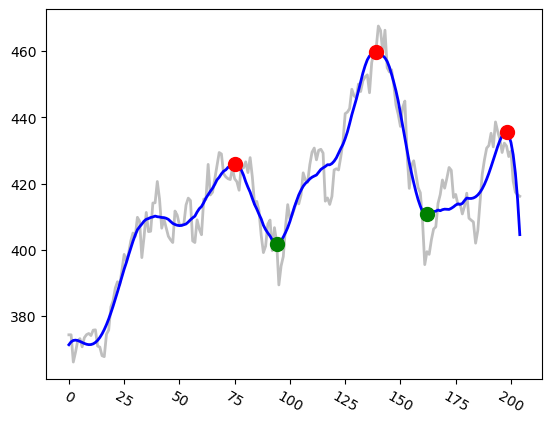

In [25]:

%matplotlib inline

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
pd.set_option('mode.chained_assignment', None)

df2 = df.iloc[0:300]

df2["close_smooth"] = savgol_filter(df2.Close, 49, 5)

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

atr = df2.atr.iloc[-1] # all the first atrs are NaN

peaks_idx, _ = find_peaks(df2.close_smooth, distance = 15, width = 3, prominence=atr)

troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = 15,width = 3, prominence=atr)

peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                 c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                   c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

'''
Check if we are on a up trend
'''
up_run_length = 0
up_run = True
while up_run:
    if 2 + up_run_length > len(peaks_idx) or 2 + up_run_length > len(troughs_idx):
        break
        
    if df2.close_smooth.iloc[peaks_idx[-1 - up_run_length]] > df2.close_smooth.iloc[peaks_idx[-2 - up_run_length]] and \
       df2.close_smooth.iloc[troughs_idx[-1 - up_run_length]] > df2.close_smooth.iloc[troughs_idx[-2 - up_run_length]]:
        up_run_length += 1
    else:
        up_run = False    
        
print(up_run_length)
      
'''
Check if we are on a down trend
'''
down_run_length = 0
down_run = True
while down_run:
    if 2 + down_run_length > len(peaks_idx) or 2 + down_run_length > len(troughs_idx):
        break
        
    if df2.close_smooth.iloc[peaks_idx[-1 - down_run_length]] > df2.close_smooth.iloc[peaks_idx[-2 - down_run_length]] and \
       df2.close_smooth.iloc[troughs_idx[-1 - down_run_length]] > df2.close_smooth.iloc[troughs_idx[-2 - down_run_length]]:
        down_run_length += 1
    else:
        down_run = False 

if up_run_length > 0:
    ax.set_facecolor((150/255, 255/255, 159/255, 0.3))  
elif down_run_length > 0:
    ax.set_facecolor((150/255, 255/180, 20/255, 0.3)) 
else:
    ax.set_facecolor("white")
        
print(down_run_length)

plt.show()